In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
pd.set_option('display.max_columns', None)

In [3]:
url = "https://minio.lab.sspcloud.fr/projet-funathon/2026/project1/data/1_input/transactions_EN.parquet"

data = pd.read_parquet(url)

In [4]:
data.shape

(9999635, 43)

In [5]:
data.head()

,trans_date,trans_year,trans_month,price,prop_type,prop_year_harm,prop_loc_dep,prop_loc_citycode,prop_loc_x,prop_loc_y,dist_tosea,n_floors,n_bath,n_show,n_sink,n_wc,n_mrooms,n_eatr,n_slr,n_kit8,n_kit9,n_washr,n_ancrooms,n_rooms,farea,has_water,has_elec,stair,has_gas,has_elevator,has_cheating,has_rchute,has_mdrainage,nth_floor,s_land_artif,s_land_agri,s_land_nat,n_garage,n_pool,n_terrace,n_attic,n_basmt,n_otherannex
0,2017-04-25,2017,4,144066.438486,1,2014,60,60370,2.106281,49.258202,10000.0,2,2,0,2,2,9,2,4,1,0,2,2,11,119,2,2,1,2,1,2,1,0,0,802,0,0,1,0,0,0,0,0
1,2012-08-12,2012,8,158839.793280,1,1987,60,60003,2.173426,49.520604,10000.0,1,1,1,1,1,6,1,3,0,1,1,2,8,119,2,2,1,0,1,2,1,2,0,859,0,0,1,0,0,0,0,0
2,2012-09-13,2012,9,70960.301727,1,2006,60,60592,1.735172,49.415124,10000.0,2,1,0,1,1,9,2,4,0,1,2,0,9,111,2,2,1,0,1,2,1,0,0,765,0,0,1,0,0,0,0,0
3,2013-02-26,2013,2,43676.516263,1,1992,60,60057,2.083790,49.420146,10000.0,2,0,1,2,1,9,1,5,0,1,2,2,11,115,2,2,1,1,1,2,1,2,0,769,0,0,1,0,0,0,0,0
4,2017-03-05,2017,3,194822.649580,1,1971,60,60513,2.382319,49.208644,10000.0,2,1,1,2,2,8,1,4,1,0,2,4,12,112,2,2,1,0,1,2,1,0,0,880,0,0,1,0,0,0,0,0


In [6]:
data.isna().mean()[data.isna().mean()>0]

prop_loc_citycode    0.001302
prop_loc_x           0.001302
prop_loc_y           0.001302
dist_tosea           0.001302
dtype: float64

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.trans_date = pd.to_datetime(data.trans_date)

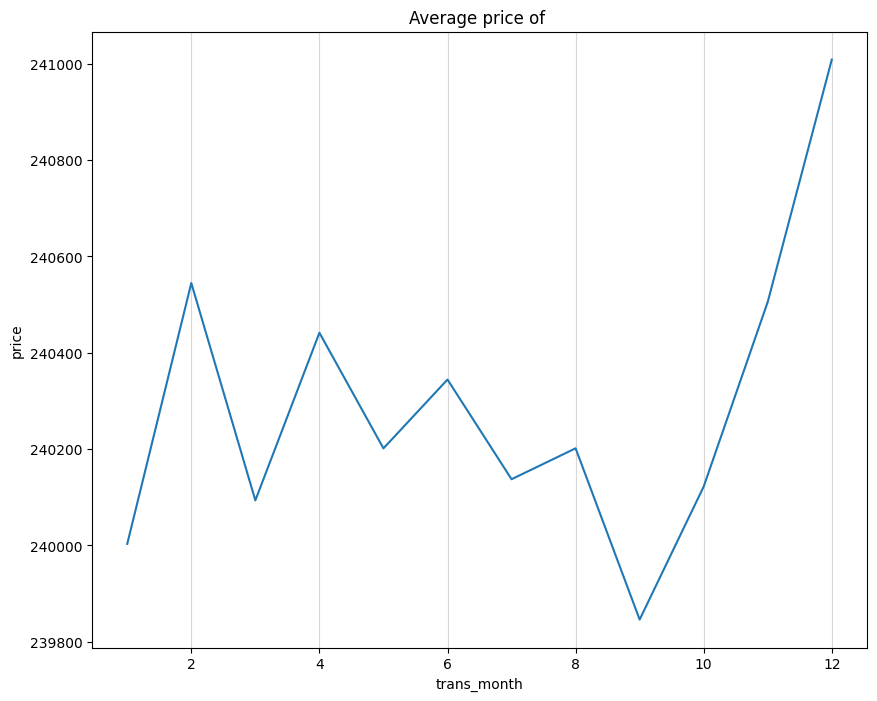

In [9]:
plt.figure(figsize=(10, 8))
plt.title("Average price of ")

sns.lineplot(data=data.groupby("trans_month")["price"].mean().reset_index(), x="trans_month", y="price")
plt.grid(True, axis="x", alpha=.5)

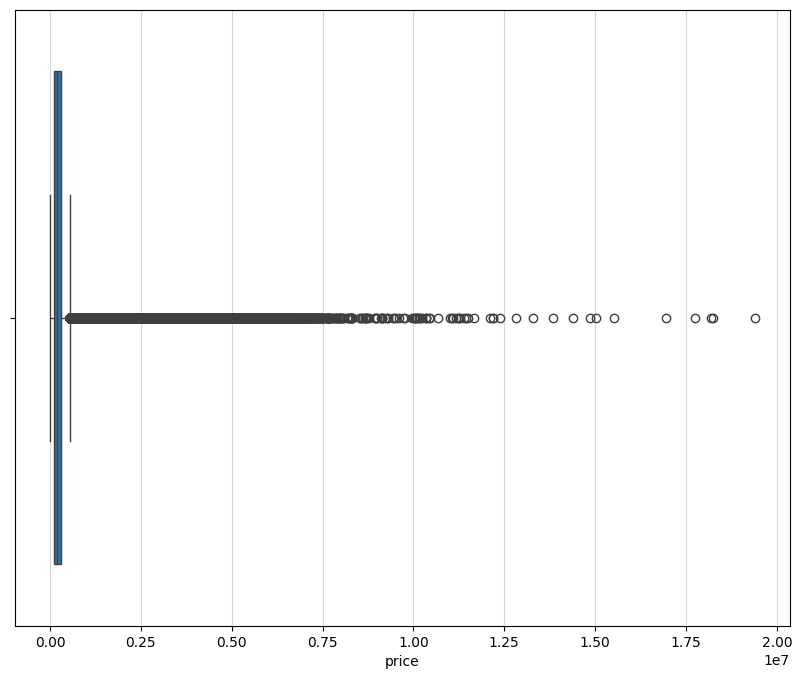

In [10]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=data, x="price")
plt.grid(True, axis="x", alpha=.5)

In [11]:
data["log_price"] = data.price.transform(np.log1p)

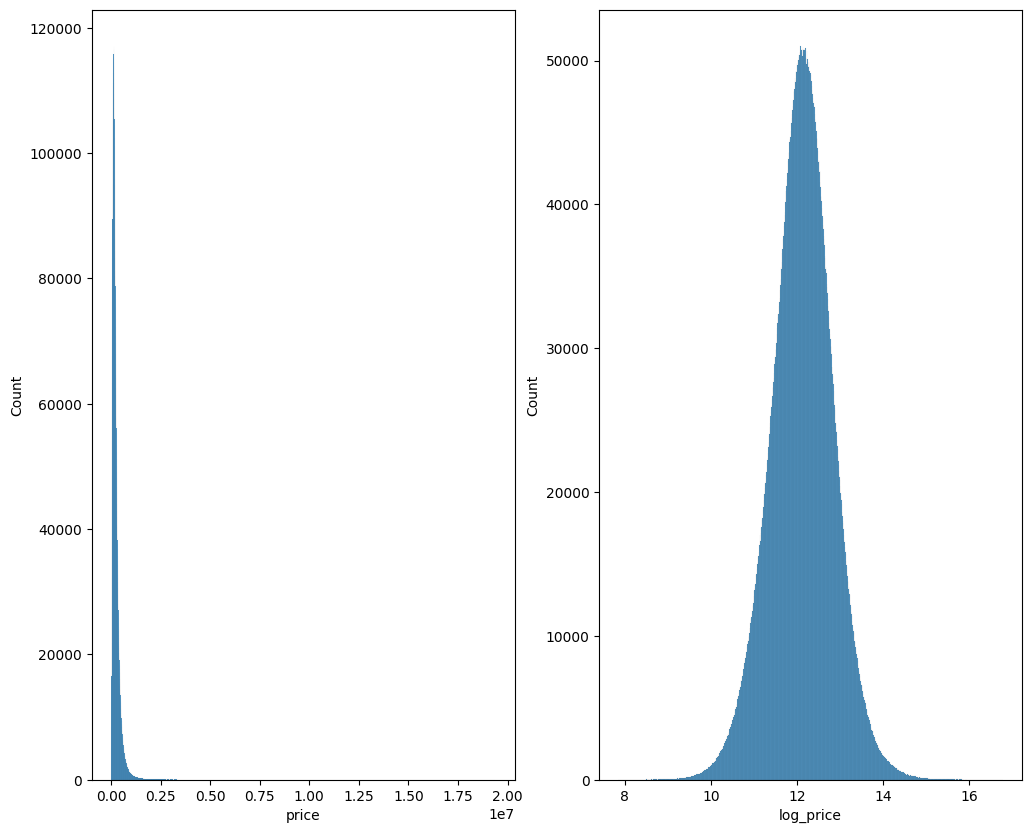

<Figure size 1000x600 with 0 Axes>

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 10))
plt.figure(figsize=(10, 6))
for i, col in enumerate(["price", "log_price"]):
    sns.histplot(data=data, x=col, ax=ax[i])
    

In [13]:
data["nan_flag"] = data.isnull().any(axis=1).astype(int)

<Axes: >

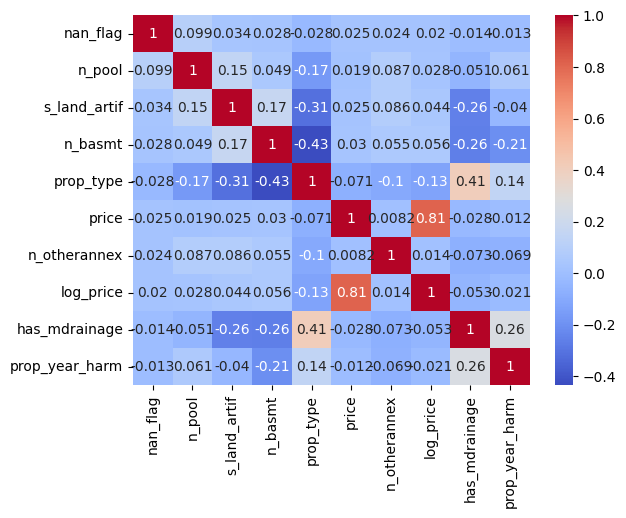

In [14]:
corr = data.select_dtypes(include="number").corr().apply(np.abs)

corr_nan = corr["nan_flag"].sort_values(ascending=False)

top_cols = corr_nan.abs().sort_values(ascending=False).head(10).index

sns.heatmap(
    data=data[top_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

<Axes: >

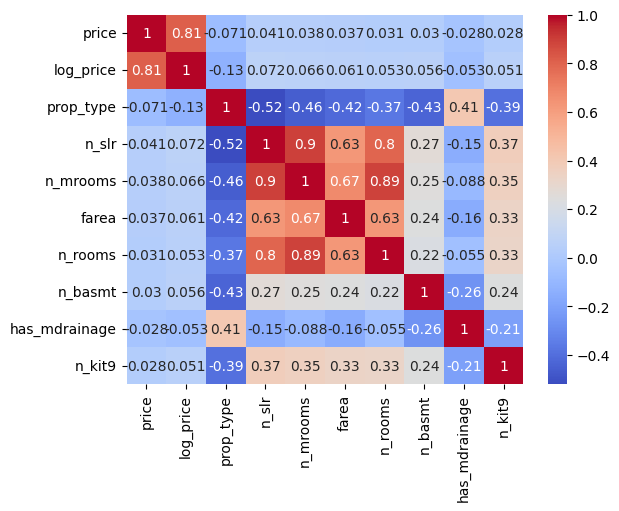

In [15]:
corr = data.select_dtypes(include="number").corr().apply(np.abs)

corr_nan = corr["price"].sort_values(ascending=False)

top_cols = corr_nan.abs().sort_values(ascending=False).head(10).index

sns.heatmap(
    data=data[top_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

In [16]:
data.trans_date.min(), data.trans_date.max()

(Timestamp('2010-01-01 00:00:00'), Timestamp('2024-12-31 00:00:00'))

In [27]:
pd.set_option('display.float_format', '{:.6f}'.format)
data.select_dtypes(np.number).var().sort_values(ascending=True)

has_elec                   0.000000
nan_flag                   0.001300
has_water                  0.036756
n_pool                     0.038071
n_otherannex               0.060046
n_terrace                  0.193150
prop_type                  0.240002
n_eatr                     0.252018
n_kit8                     0.252507
n_kit9                     0.257009
n_bath                     0.268462
n_attic                    0.269843
stair                      0.276599
n_wc                       0.292553
has_rchute                 0.311571
n_washr                    0.346652
has_elevator               0.349555
n_garage                   0.355956
n_show                     0.357157
n_basmt                    0.383966
log_price                  0.525222
has_cheating               0.586492
has_mdrainage              0.659495
n_sink                     0.698790
has_gas                    0.824671
n_ancrooms                 1.234941
n_slr                      1.679615
n_mrooms                   3

In [17]:
X = data.select_dtypes(np.number).dropna(how="any", axis=0)

In [18]:
pca1 = PCA()
pca2 = PCA(n_components=2)
pca1.fit_transform(X)

array([[-9.60160878e+04, -6.23226752e+02,  8.62896273e+01, ...,
        -9.76020844e-04,  2.43820333e-08,  0.00000000e+00],
       [-8.12427254e+04, -6.25586325e+02,  8.61464874e+01, ...,
        -5.60965036e-03,  4.87279328e-09,  0.00000000e+00],
       [-1.69122226e+05, -6.07618215e+02,  8.83531545e+01, ...,
         3.22143039e-02,  2.64150746e-08,  0.00000000e+00],
       ...,
       [ 4.52922410e+05, -7.57476181e+02,  6.50470210e+01, ...,
         1.90046343e-03, -7.35470129e-09,  0.00000000e+00],
       [-3.68699344e+04, -6.48994718e+02,  8.01878803e+01, ...,
         1.79657707e-02, -2.04695820e-08,  0.00000000e+00],
       [-1.58155260e+04, -6.53656844e+02,  7.95379415e+01, ...,
        -7.18537442e-02,  4.51614897e-08,  0.00000000e+00]],
      shape=(9986618, 42))

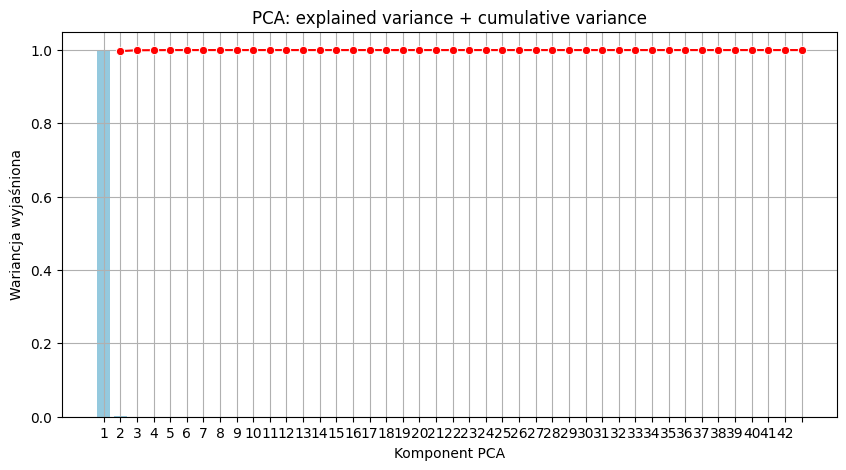

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=np.arange(1, len(pca1.explained_variance_ratio_) + 1),
    y=pca1.explained_variance_ratio_,
    color="skyblue"
)

sns.lineplot(
    x=np.arange(1, len(pca1.explained_variance_ratio_) + 1),
    y=np.cumsum(pca1.explained_variance_ratio_),
    marker="o",
    color="red"
)

plt.xlabel("Komponent PCA")
plt.ylabel("Wariancja wyjaśniona")
plt.title("PCA: explained variance + cumulative variance")
plt.xticks(np.arange(0, len(pca1.explained_variance_ratio_) + 1))
plt.grid(True)


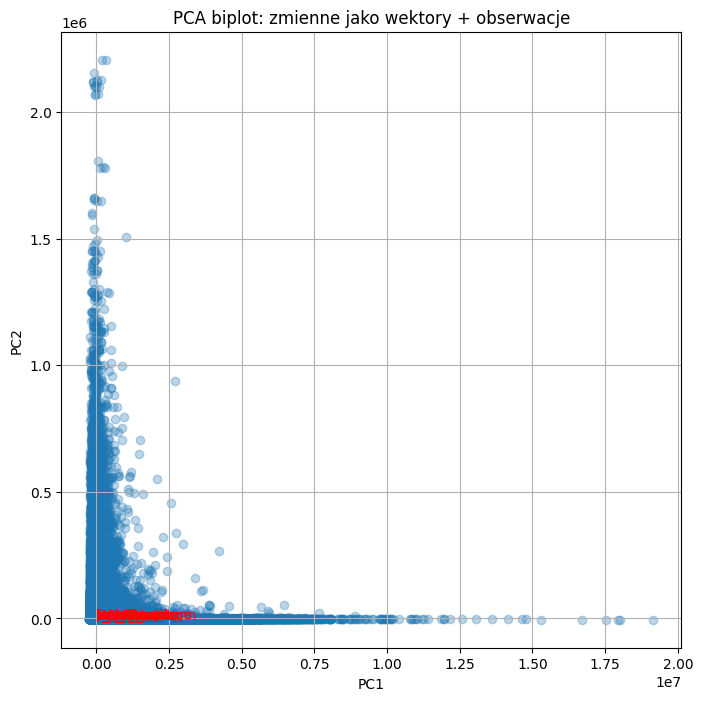

In [20]:
pca1.fit(X)
pca2.fit(X)

X_pca2 = pca2.transform(X)

loadings = pca2.components_.T

plt.figure(figsize=(8,8))

plt.scatter(X_pca2[:, 0], X_pca2[:, 1], alpha=0.3)

# lepsze skalowanie wektorów (normalizacja)
scale = 3 / np.max(np.abs(loadings))

for i in range(X.shape[1]):
    plt.arrow(
        0, 0,
        loadings[i, 0] * scale,
        loadings[i, 1] * scale,
        color="red",
        alpha=0.7
    )
    plt.text(
        loadings[i, 0] * scale * 1.1,
        loadings[i, 1] * scale * 1.1,
        X.columns[i],
        color="red",
        fontsize=9
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA biplot: zmienne jako wektory + obserwacje")
plt.grid()
plt.show()